In [43]:
import pandas as pd
import json
import regex as re
import matplotlib.patches as patches

from matplotlib.cm import Reds, Blues, Greys
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
from matplotlib.colors import LinearSegmentedColormap

In [44]:
accessed_urls_size_data = pd.read_csv('src/accessed_url_size_3_filtered.csv')

accessed_urls_size_data = pd.concat([accessed_urls_size_data.loc[accessed_urls_size_data['http_status']== 200],accessed_urls_size_data.loc[accessed_urls_size_data['http_status']== 202]])

accessed_urls_size_data['category'] = accessed_urls_size_data['category'].replace('abstain','abstain_gpt-o4-mini')
accessed_urls_size_data['category'] = accessed_urls_size_data['category'].replace('factual','factual_gpt-o4-mini')
accessed_urls_size_data['category'] = accessed_urls_size_data['category'].replace('transactional','transactional_gpt-o4-mini')
accessed_urls_size_data['category'] = accessed_urls_size_data['category'].replace('navigational','navigational_gpt-o4-mini')
accessed_urls_size_data['category'] = accessed_urls_size_data['category'].replace('instrumental','instrumental_gpt-o4-mini')

accessed_urls_size_data.head()

,meta_path,prompt_id,category,url,http_status,bytes,is_cited,note,attempt,final
0,results/abstain/network-logs-prompt-151_202508...,151,abstain_gpt-o4-mini,https://en.wikipedia.org/wiki/KnightCite,200.0,16746.0,True,NaN,1,True
1,results/abstain/network-logs-prompt-151_202508...,151,abstain_gpt-o4-mini,https://en.wikipedia.org/wiki/BibDesk,200.0,29076.0,False,NaN,1,True
2,results/abstain/network-logs-prompt-156_202508...,156,abstain_gpt-o4-mini,https://www.tenable.com/blog/microsofts-july-2...,200.0,35970.0,True,NaN,1,True
3,results/abstain/network-logs-prompt-156_202508...,156,abstain_gpt-o4-mini,https://www.theregister.com/2025/07/08/microso...,200.0,13271.0,True,NaN,1,True
4,results/abstain/network-logs-prompt-151_202508...,151,abstain_gpt-o4-mini,https://www.mybib.com/,200.0,23726.0,False,NaN,1,True


In [45]:
df_by_query = accessed_urls_size_data.groupby(['prompt_id','category'],as_index=False)[['prompt_id','category','bytes']].sum('bytes')

# df_by_category = df_by_query.groupby(['category'],as_index=True)[['category','bytes']].mean()
df_by_category = df_by_query.groupby(['category'], as_index=True)[['bytes']].mean()


In [46]:
df_by_query.groupby('category').count()

,prompt_id,bytes
category,,
abstain_gpt-5,229,229
abstain_gpt-5-thinking,19,19
abstain_gpt-o4-mini,265,265
abstain_opus-4.1,216,216
abstain_sonnet-4,288,288
factual_gpt-5,304,304
factual_gpt-5-thinking,16,16
factual_gpt-o4-mini,286,286
factual_opus-4.1,225,225


In [47]:
df_by_category

,bytes
category,
abstain_gpt-5,2.006886e+06
abstain_gpt-5-thinking,1.072449e+07
abstain_gpt-o4-mini,2.926932e+06
abstain_opus-4.1,7.144805e+05
abstain_sonnet-4,7.167336e+05
factual_gpt-5,1.905004e+06
factual_gpt-5-thinking,1.116609e+07
factual_gpt-o4-mini,2.298247e+06
factual_opus-4.1,8.832619e+05


In [48]:
# df_by_query_is_cited = 
df_by_query_is_cited = accessed_urls_size_data.loc[accessed_urls_size_data['is_cited']==True].groupby(['prompt_id','category'],as_index=False)[['prompt_id','category','bytes']].sum('bytes')

df_by_category_is_cited = df_by_query_is_cited.groupby(['category'],as_index=True)[['bytes']].mean()

In [49]:
df_by_category_is_cited

,bytes
category,
abstain_gpt-5,1.033070e+06
abstain_gpt-5-thinking,1.331668e+06
abstain_gpt-o4-mini,5.541032e+05
abstain_opus-4.1,2.397088e+05
abstain_sonnet-4,2.833666e+05
factual_gpt-5,1.041575e+06
factual_gpt-5-thinking,6.021246e+05
factual_gpt-o4-mini,4.606784e+05
factual_opus-4.1,2.490878e+05


In [50]:
df_by_category-df_by_category_is_cited

,bytes
category,
abstain_gpt-5,9.738156e+05
abstain_gpt-5-thinking,9.392826e+06
abstain_gpt-o4-mini,2.372828e+06
abstain_opus-4.1,4.747717e+05
abstain_sonnet-4,4.333670e+05
factual_gpt-5,8.634289e+05
factual_gpt-5-thinking,1.056396e+07
factual_gpt-o4-mini,1.837569e+06
factual_opus-4.1,6.341741e+05


In [51]:
# import pandas as pd

# # Load CSV
# df = pd.read_csv("src/accessed_url_size_3_filtered.csv")

# # Drop rows where http_status is 403, 429, or None/NaN
# df_cleaned = df[~df["http_status"].isin([403, 429])]
# df_cleaned = df_cleaned.dropna(subset=["http_status"])

# # Save to new CSV
# df_cleaned.to_csv("src/accessed_url_size_3_filtered.csv", index=False)


In [52]:
# load
with open('aggregated_data.json','r',encoding='utf-8') as f:
    data_aggr = json.load(f)

CATEGORIES = ['abstain','factual','navigational','instrumental','transactional']

# rename bare category keys → "{category}_gpt-o4-mini"
for cat in CATEGORIES:
    if cat in data_aggr:
        data_aggr[f"{cat}_gpt-o4-mini"] = data_aggr.pop(cat)


In [53]:
records = []

for category, prompts in data_aggr.items():
    for prompt_id, details in prompts.items():
        search_count = len(details.get("search_string", []))
        if search_count == 0:
            continue
        records.append({
            "category": category,
            "prompt_id": prompt_id,
            "search_string_number": search_count,
            "cited" : len(details.get("urls_cited",[]))
        })

# Convert to DataFrame
llm_cited_data = pd.DataFrame(records)
llm_cited_data

,category,prompt_id,search_string_number,cited
0,transactional_sonnet-4,network-logs-prompt-23_20250915_234030,1,8
1,transactional_sonnet-4,network-logs-prompt-26_20250915_234030,1,5
2,transactional_sonnet-4,network-logs-prompt-33_20250915_234030,1,6
3,transactional_sonnet-4,network-logs-prompt-32_20250915_234030,1,7
4,transactional_sonnet-4,network-logs-prompt-21_20250915_234030,1,4
...,...,...,...,...
3538,transactional_gpt-o4-mini,network-logs-prompt-3_20250805_025105,2,8
3539,transactional_gpt-o4-mini,network-logs-prompt-2_20250805_025105,11,16
3540,transactional_gpt-o4-mini,network-logs-prompt-15_20250805_025105,5,9
3541,transactional_gpt-o4-mini,network-logs-prompt-4_20250805_025105,9,13


In [54]:
# If df doesn't exist (e.g., fresh session), reconstruct it safely from the prior logic.
try:
    llm_cited_data
except NameError:
    llm_cited_data = pd.DataFrame(columns=["category","prompt_id","search_string_number"])

def extract_prompt_number(pid: str):
    if not isinstance(pid, str):
        return None
    m = re.search(r"network-logs-prompt-(\d+)_", pid)
    return int(m.group(1)) if m else None

# Create a cleaned column and replace the existing prompt_id
llm_cited_data["prompt_id"] = llm_cited_data["prompt_id"].apply(extract_prompt_number)

# Sort for readability
llm_cited_data = llm_cited_data.sort_values(["category","prompt_id",'cited'], ignore_index=True)
llm_cited_data

,category,prompt_id,search_string_number,cited
0,abstain_gpt-5,1,1,21
1,abstain_gpt-5,2,1,19
2,abstain_gpt-5,3,1,20
3,abstain_gpt-5,4,1,11
4,abstain_gpt-5,5,1,15
...,...,...,...,...
3538,transactional_sonnet-4,39,1,6
3539,transactional_sonnet-4,40,1,5
3540,transactional_sonnet-4,41,1,4
3541,transactional_sonnet-4,42,1,4


In [55]:
import numpy as np
import pandas as pd

# Ensure prompt_id in both dataframes are integers for merging
accessed_urls_size_data["prompt_id"] = accessed_urls_size_data["prompt_id"].astype(int)
llm_cited_data["prompt_id"] = llm_cited_data["prompt_id"].astype(int)

# Define the forecasting function based on simplified model
def forecast_human_pages(k, c1=1.96, r=0.5):
    """Forecast expected number of human-opened pages given k LLM searches."""
    if k <= 0:
        return 0
    # Geometric series sum: c1 * (1 - r**k) / (1 - r)
    return c1 * (1 - r**k) / (1 - r)

# Prepare results list
results = []

# Group metadata by category and prompt_id for efficient access
grouped_meta = accessed_urls_size_data.groupby(["category", "prompt_id"])

for _, row in llm_cited_data.iterrows():
    category = row["category"]
    pid = row["prompt_id"]
    search_count = int(row["search_string_number"])
    cited_count = row["cited"]  
    
    # Forecast expected human page opens using the derived model
    human_forecast = forecast_human_pages(search_count)
    
    # Calculate number of URLs to sample
    n_needed = round(human_forecast * 1.5)
    
    # Extract group (if it exists)
    if (category, pid) in grouped_meta.groups:
        group = grouped_meta.get_group((category, pid))
        cited = group[group["is_cited"] == True]
        
        if len(cited) > 0:
            sampled = cited.sample(n=min(n_needed, len(cited)), random_state=42)
            byte_sum = sampled["bytes"].sum()
        else:
            byte_sum = 0
    else:
        byte_sum = 0
    
    results.append({
        "category": category,
        "prompt_id": pid,
        "search_string_number": search_count,
        "cited_urls_count": cited_count,
        "cited_bytes_sum": byte_sum,
        "forecasted_human_pages": human_forecast
    })

# Convert results to DataFrame
summary_df = pd.DataFrame(results)


In [56]:
summary_df

,category,prompt_id,search_string_number,cited_urls_count,cited_bytes_sum,forecasted_human_pages
0,abstain_gpt-5,1,1,21,126456.0,1.96
1,abstain_gpt-5,2,1,19,248176.0,1.96
2,abstain_gpt-5,3,1,20,44698.0,1.96
3,abstain_gpt-5,4,1,11,376198.0,1.96
4,abstain_gpt-5,5,1,15,203578.0,1.96
...,...,...,...,...,...,...
3538,transactional_sonnet-4,39,1,6,568574.0,1.96
3539,transactional_sonnet-4,40,1,5,343676.0,1.96
3540,transactional_sonnet-4,41,1,4,65481.0,1.96
3541,transactional_sonnet-4,42,1,4,69592.0,1.96


In [57]:
avg_by_category = summary_df.groupby("category")[["cited_bytes_sum", "cited_urls_count","search_string_number"]].mean().reset_index()
avg_by_category = avg_by_category.set_index('category')
# avg_by_category.loc[avg_by_category['search_string_number'] < 1, 'search_string_number'] = 1
avg_by_category

,cited_bytes_sum,cited_urls_count,search_string_number
category,,,
abstain_gpt-5,161796.944904,11.214876,1.000000
abstain_gpt-5-thinking,517247.421053,12.578947,10.473684
abstain_gpt-o4-mini,314490.924051,10.107595,5.250000
abstain_opus-4.1,150080.968153,4.407643,1.019108
abstain_sonnet-4,155527.857143,5.052198,1.030220
factual_gpt-5,311020.751381,12.646409,1.000000
factual_gpt-5-thinking,326915.062500,6.312500,9.125000
factual_gpt-o4-mini,261184.587692,7.273846,4.153846
factual_opus-4.1,176453.691489,3.946809,1.015957


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import Union

SeriesOrDF = Union[pd.Series, pd.DataFrame]

def to_series(obj: SeriesOrDF, name: str):
    """Convert a Series or single-column DataFrame to a pandas Series and set a name."""
    if isinstance(obj, pd.Series):
        s = obj.copy()
        s.name = name
        return s
    if isinstance(obj, pd.DataFrame):
        if obj.shape[1] == 1:
            s = obj.iloc[:, 0].copy()
            s.name = name
            return s
        raise ValueError("DataFrame must have exactly one column.")
    raise TypeError("Input must be a pandas Series or single-column DataFrame.")

def plot_category_bytes(
    df_by_category: SeriesOrDF,
    df_by_category_is_cited: SeriesOrDF,
    avg_by_category: SeriesOrDF,
    title: str = "Bytes by Category (accessed / cited / forecasted / non-cited)",
    save_path: str = "bytes_by_category_plot.png",
    log_scale: bool = False,
    figsize=(12,6)
):
    """
    Plots:
      - df_by_category (accessed URLs total bytes)
      - df_by_category_is_cited (cited URLs bytes)
      - avg_by_category (forecasted urls bytes)
      - non-cited = df_by_category - df_by_category_is_cited

    Inputs can be pd.Series or single-column pd.DataFrame indexed by 'category'.
    """
    # Convert inputs to Series with meaningful names
    total_s = to_series(df_by_category, "accessed_bytes")
    cited_s  = to_series(df_by_category_is_cited, "cited_bytes")
    avg_s    = to_series(avg_by_category['cited_bytes_sum'], "forecasted_bytes")
    cited_url_s    = to_series(avg_by_category['cited_urls_count'], "cited_url_count")
    search_count_s    = to_series(avg_by_category['search_string_number'], "search_string_count")

    # Build union of all categories and align series
    all_cats = sorted(set(total_s.index) | set(cited_s.index) | set(avg_s.index) | set(cited_url_s.index)| set(search_count_s.index))
    total_aligned = total_s.reindex(all_cats).fillna(0)
    cited_aligned = cited_s.reindex(all_cats).fillna(0)
    cited_url_aligned = cited_url_s.reindex(all_cats).fillna(0)
    search_count_aligned = search_count_s.reindex(all_cats).fillna(0)
    avg_aligned = avg_s.reindex(all_cats).fillna(0)

    # Compute non-cited (difference)
    non_cited = (total_aligned - cited_aligned).rename("non_cited_bytes")

    # Combined DataFrame (for inspection or export if desired)
    combined = pd.concat([
        total_aligned.rename("accessed_bytes"),
        cited_aligned.rename("cited_bytes"),
        non_cited,
        avg_aligned.rename("forecasted_bytes"),
        cited_url_aligned.rename('cited_url_count'),
        search_count_aligned.rename('search_count'),
    ], axis=1)

    # Plot 
    # Create main figure and axis 
    fig, ax = plt.subplots(figsize=figsize) 
    x = np.arange(len(combined.index)) 
    # Convert bytes to KB 
    cited_kb = combined["cited_bytes"] / 1024.0 
    forecasted_kb = combined["forecasted_bytes"] / 1024.0 
    # Pastel colors 
    pastel_colors = { "cited": "#aec6cf", # pastel blue 
                     "forecasted": "#ffb347" # pastel orange 
                     } 
    # Plot
    ax.plot(x, cited_kb, marker='s', color=pastel_colors["cited"], label="Size of Cited URLs (KB)")
    ax.plot(x, forecasted_kb, marker='d', color=pastel_colors["forecasted"], label="Size of Forecasted URLs (KB)")
    ax.set_xlabel("Category")
    ax.set_ylabel("KB")
    ax.set_xticks(x)
    ax.set_xticklabels(combined.index, rotation=45, ha="right")
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7) 
    if log_scale: ax.set_yscale("log") 
    ax.legend(loc="best") 
    # ax.set_title(title) 
    plt.tight_layout() 
    plt.savefig(save_path, dpi=150) 
    plt.show()

    def identify_family(cat: str) -> str:
        s = cat.lower()
        if "gpt" in s:
            return "gpt"
        if any(k in s for k in ["sonnet", "opus", "haiku", "claude", "anthropic"]):
            return "anthropic"
        return "other"
    
    def plot_heatmap_label_colored(combined, outpath="heatmap_label_colors.png"):
        metrics = ["cited_url_count", "cited_bytes", "forecasted_bytes", "search_count"]
        M_raw = combined[metrics].copy()

        # KB versions for annotation
        cited_kb = (combined["cited_bytes"] / 1024.0).values
        forecasted_kb = (combined["forecasted_bytes"] / 1024.0).values

        # Prep matrix for normalization
        # --- Normalize with shared scale for byte-based columns ---
        M = M_raw.copy()
        M["cited_bytes"] = M["cited_bytes"] / 1024.0
        M["forecasted_bytes"] = M["forecasted_bytes"] / 1024.0

        # Take log10 safely, but keep NaN for 0 or None
        for col in ["cited_bytes", "forecasted_bytes"]:
            M[col] = np.log10(M[col].replace(0, np.nan))

        # Compute shared min/max ignoring NaN
        shared_min = np.nanmin(M[["cited_bytes", "forecasted_bytes"]].values)
        shared_max = np.nanmax(M[["cited_bytes", "forecasted_bytes"]].values)

        # Apply shared scaling (ignoring NaNs)
        for col in ["cited_bytes", "forecasted_bytes"]:
            M[col] = (M[col] - shared_min) / (shared_max - shared_min)

        # Normalize other columns independently, also ignoring NaNs and zeros
        for col in ["cited_url_count", "search_count"]:
            col_data = M[col].replace(0, np.nan)
            col_min = np.nanmin(col_data)
            col_max = np.nanmax(col_data)
            M[col] = (col_data - col_min) / (col_max - col_min)



        # --- custom purple colormap ---
        purple_hex = "#9B52E0"
        purple_cmap = LinearSegmentedColormap.from_list("custom_purple", ["#ffffff", purple_hex])

        fig, ax = plt.subplots(figsize=(12, max(6, len(M) / 3)))
        # fig, ax = plt.subplots(figsize=(12,3))
        # fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(M.values, aspect="auto", cmap=purple_cmap)

        # Axis ticks
        ax.set_yticks(np.arange(len(M.index)))
        ax.set_yticklabels(M.index)
        ax.set_xticks(np.arange(len(metrics)))
        ax.set_xticklabels(
            ["Cited URLs Count\nper query (avg)", "Cited URLs Size\nper query (avg)", "Forcasted URLs Size\nper query (avg)", "Search Strings\nper query (avg)"],
            rotation=0, ha="center", fontsize=14
        )

        # Annotate values
        for i in range(len(M.index)):
            for j, col in enumerate(metrics):
                val = M_raw.iloc[i, j]
                if val == 0:
                    text = "Unknown"   # or "NA"
                    color = "gray"
                else:
                    if col == "cited_bytes":
                        text = f"{cited_kb[i]:.1f} KB"
                    elif col == "forecasted_bytes":
                        text = f"{forecasted_kb[i]:.1f} KB" if forecasted_kb[i] > 0 else "0"
                    else:
                        text = f"{val:.1f}"
                    color = "black"

                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=16)


        # Color y-axis labels by family
        family_colors = {"gpt": "#0fa47f", "anthropic": "#db6a48", "other": "gray"}
        for tick, cat in zip(ax.get_yticklabels(), M.index):
            fam = identify_family(cat)
            tick.set_color(family_colors.get(fam, "gray"))
            tick.set_fontweight("bold")
            tick.set_fontsize(16)

        fig.colorbar(im, ax=ax, shrink=0.8, label="Normalized value")
        fig.tight_layout()
        # fig.savefig(outpath, dpi=150)
        plt.savefig("images/cost_heatmap_overall.svg",format='svg', dpi=200)
        plt.show()

    plot_heatmap_label_colored(combined=combined)

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(combined.index))

    # Convert bytes to KB
    cited_kb = (combined["cited_bytes"] / 1024.0).values
    forecasted_kb = (combined["forecasted_bytes"] / 1024.0).values

    # Pastel colors (kept)
    pastel_colors = {
        "cited": "#aec6cf",       # pastel blue
        "forecasted": "#ffb347"   # pastel orange
    }

    # Slight x-offset so stems/markers don't overlap
    dx = 0.13
    x_cited = x - dx
    x_fore  = x + dx

    # Baseline for stems
    if log_scale:
        # log scale can't start at 0; use a small positive baseline
        pos_vals = np.concatenate([cited_kb[cited_kb > 0], forecasted_kb[forecasted_kb > 0]])
        base = (pos_vals.min() * 0.5) if pos_vals.size > 0 else 1e-3
    else:
        base = 0.0

    # --- Lollipop stems ---
    ax.vlines(x_cited, base, cited_kb, color=pastel_colors["cited"], linewidth=4, alpha=0.9)
    ax.vlines(x_fore,  base, forecasted_kb, color=pastel_colors["forecasted"], linewidth=4, alpha=0.9)

    # --- Tips (markers) ---
    ax.scatter(x_cited, cited_kb, marker='o', s=155, color=pastel_colors["cited"],
            edgecolors="none", label="Size of Cited URLs (KB)", zorder=3)
    scatter_cited= ax.scatter(x_cited, cited_kb, marker='+', s=65, color='black',
            edgecolors="none", label="Size of Cited URLs (KB)", zorder=3)
    ax.scatter(x_fore, forecasted_kb, marker='o', s=155, color=pastel_colors["forecasted"],
            edgecolors="none", label="Size of Forecasted URLs  (KB)", zorder=3)
    scatter_fore =ax.scatter(x_fore, forecasted_kb, marker='x', s=55, color='black',
            edgecolors="none", label="Size of Forecasted URLs  (KB)", zorder=3)

    # Axes & grid (kept)
    ax.set_xlabel("Category")
    ax.set_ylabel("KB")
    ax.set_xticks(x)
    ax.set_xticklabels(combined.index, rotation=45, ha="right")
    ax.grid(axis='y', linestyle='--', linewidth=1.5, alpha=0.7)

    # Optional log scale
    if log_scale:
        ax.set_yscale("log")

    legend_handles = [scatter_cited, scatter_fore]
    legend_labels = ["Size of Cited URLs (KB)", "Size of Forecasted URLs (KB)"]

    # Use the custom lists to create the legend
    ax.legend(legend_handles, legend_labels, loc="best")

    plt.tight_layout()
    plt.savefig(save_path.replace(".svg","") + "lolipop.svg", dpi=150)
    plt.show()

    return combined  # return the numeric table for further use

# -------------------------
# Example usage (uncomment / adapt to your environment):
#
# combined_df = plot_category_bytes(df_by_category, df_by_category_is_cited, avg_by_category,
#                                   save_path="bytes_by_category_plot.png",
#                                   log_scale=False)
# print(combined_df.head())
#
# -------------------------


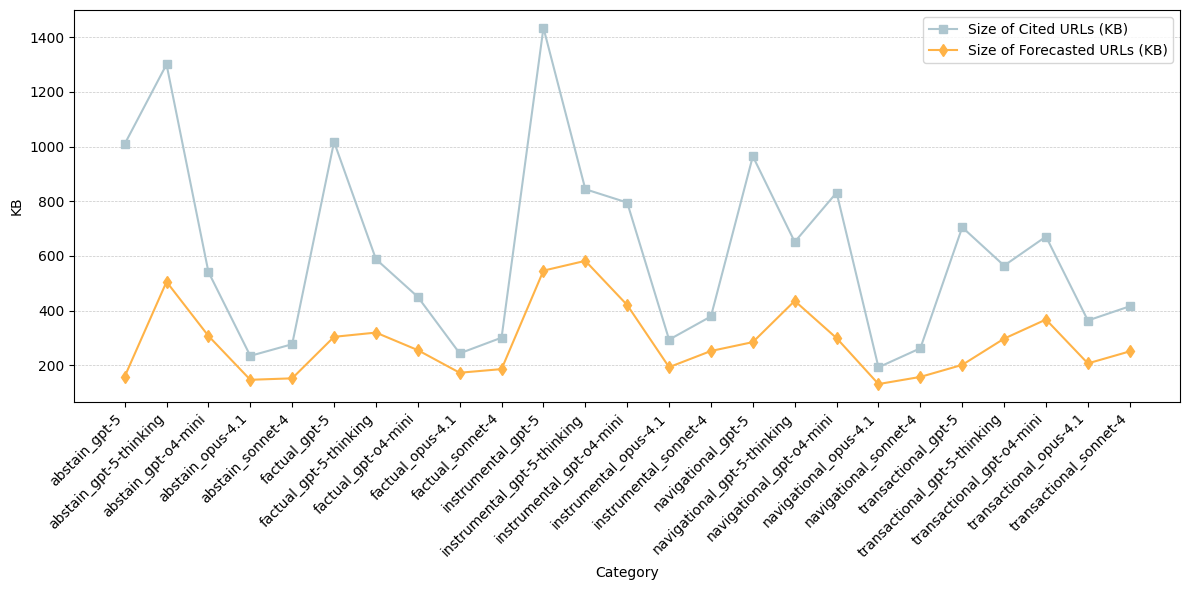

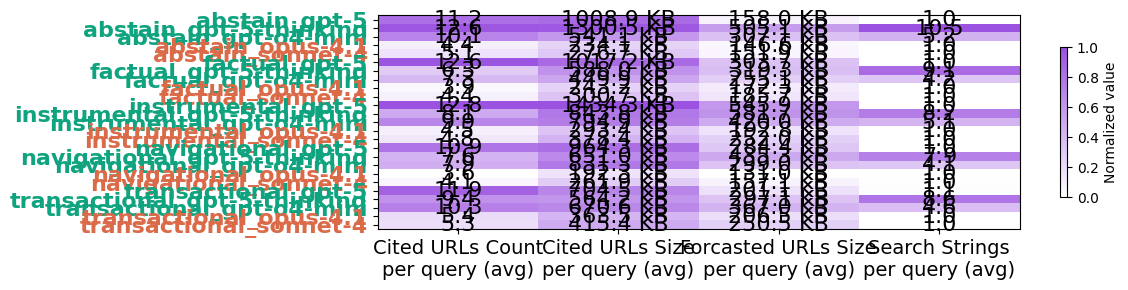

C:\Users\itsff\AppData\Local\Temp\ipykernel_25824\620667515.py:223: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  scatter_cited= ax.scatter(x_cited, cited_kb, marker='+', s=65, color='black',
C:\Users\itsff\AppData\Local\Temp\ipykernel_25824\620667515.py:227: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  scatter_fore =ax.scatter(x_fore, forecasted_kb, marker='x', s=55, color='black',


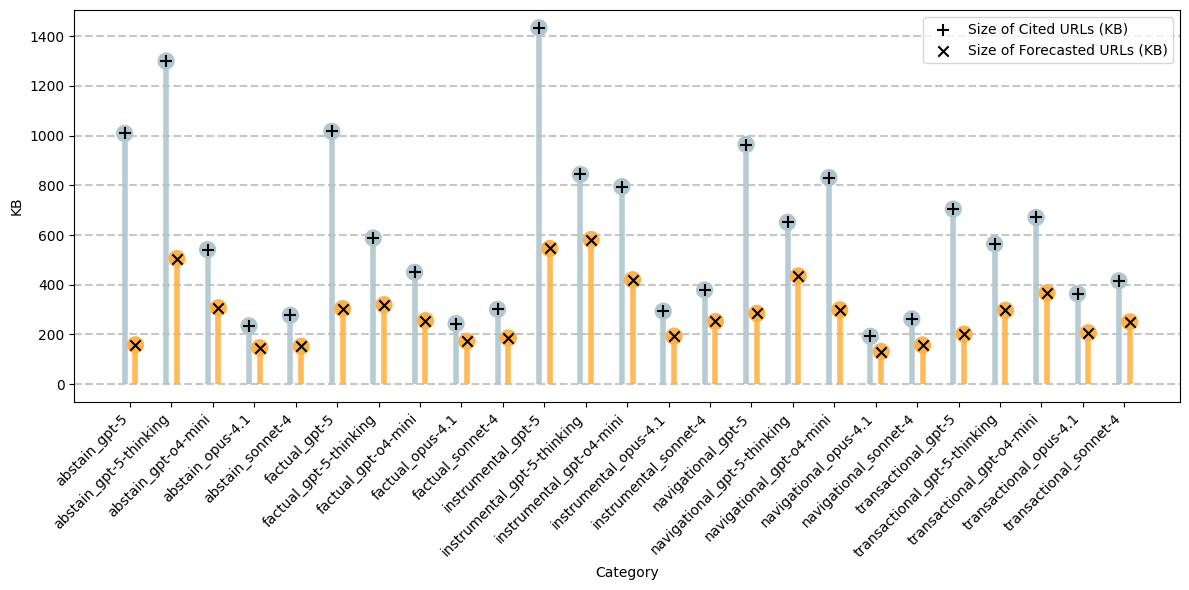

                        accessed_bytes   cited_bytes  non_cited_bytes  \
category                                                                
abstain_gpt-5             2.006886e+06  1.033070e+06     9.738156e+05   
abstain_gpt-5-thinking    1.072449e+07  1.331668e+06     9.392826e+06   
abstain_gpt-o4-mini       2.926932e+06  5.541032e+05     2.372828e+06   
abstain_opus-4.1          7.144805e+05  2.397088e+05     4.747717e+05   
abstain_sonnet-4          7.167336e+05  2.833666e+05     4.333670e+05   

                        forecasted_bytes  cited_url_count  search_count  
category                                                                 
abstain_gpt-5              161796.944904        11.214876      1.000000  
abstain_gpt-5-thinking     517247.421053        12.578947     10.473684  
abstain_gpt-o4-mini        314490.924051        10.107595      5.250000  
abstain_opus-4.1           150080.968153         4.407643      1.019108  
abstain_sonnet-4           155527.857143    

In [59]:
combined_df = plot_category_bytes(df_by_category['bytes'], df_by_category_is_cited['bytes'], avg_by_category,
                                  save_path="images/cost_chart.svg",
                                  log_scale=False)
print(combined_df.head())

In [60]:
df = df_by_category.reset_index().rename(columns={'index': 'category'})

# Extract model name (everything after the first underscore)
df['model'] = df['category'].str.split('_').str[1]

# Group by model and calculate mean
averages_by_cat = df.groupby('model')['bytes'].mean()
averages_by_cat

model
gpt-5             1.830633e+06
gpt-5-thinking    9.021101e+06
gpt-o4-mini       3.089881e+06
opus-4.1          7.478597e+05
sonnet-4          9.914242e+05
Name: bytes, dtype: float64

In [61]:
df = df_by_category_is_cited.reset_index().rename(columns={'index': 'category'})

# Extract model name (everything after the first underscore)
df['model'] = df['category'].str.split('_').str[1]

# Group by model and calculate mean
averages_by_cat_is_cited = df.groupby('model')['bytes'].mean()
averages_by_cat_is_cited 

model
gpt-5             1.050440e+06
gpt-5-thinking    8.084361e+05
gpt-o4-mini       6.733573e+05
opus-4.1          2.716592e+05
sonnet-4          3.344759e+05
Name: bytes, dtype: float64

In [62]:
df = avg_by_category.reset_index().rename(columns={'index': 'category'})

# Extract model name (everything after the first underscore)
df['model'] = df['category'].str.split('_').str[1]

# Group by model and calculate mean
forcast_overall = df.groupby('model')[['cited_bytes_sum','cited_urls_count','search_string_number']].mean()
forcast_overall
forcast_overall.loc['gpt-5', 'search_string_number'] = None
forcast_overall.loc['gpt-5', 'cited_bytes_sum'] = None
forcast_overall

,cited_bytes_sum,cited_urls_count,search_string_number
model,,,
gpt-5,NaN,11.913294,NaN
gpt-5-thinking,437954.270704,8.801819,8.860294
gpt-o4-mini,337556.096031,9.105273,4.633998
opus-4.1,173898.220856,4.368935,1.016851
sonnet-4,204206.596522,4.737196,1.022961


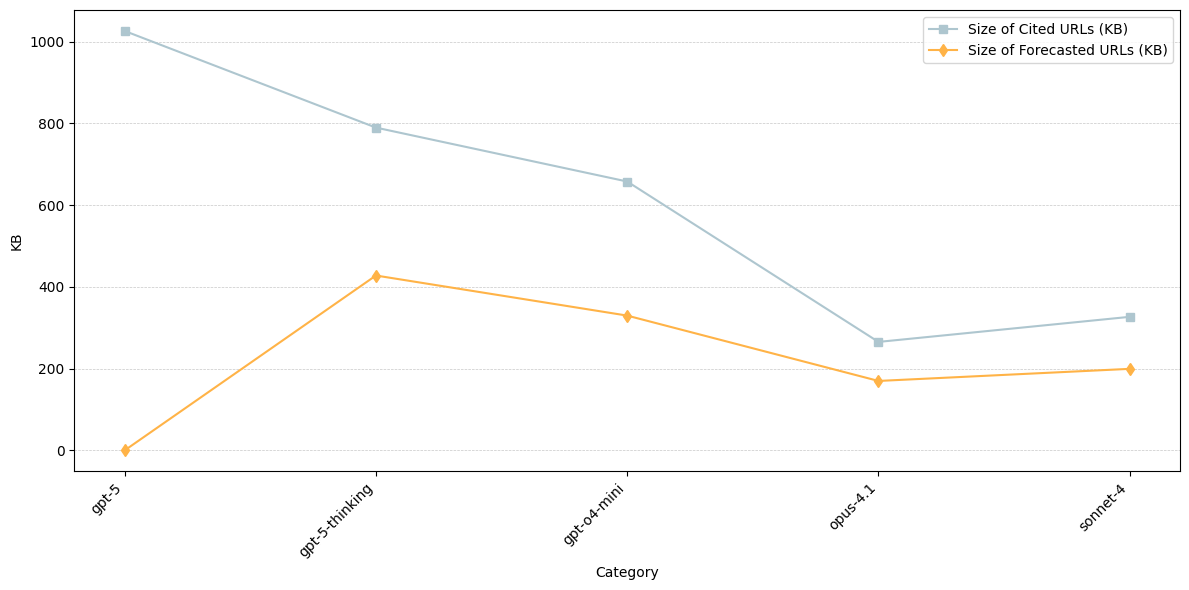

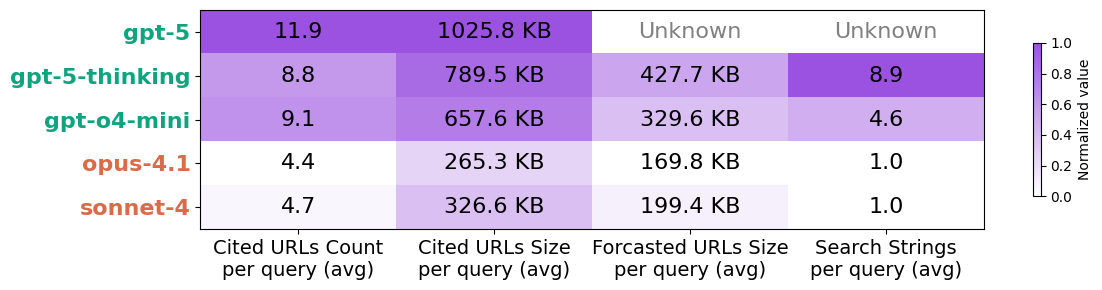

C:\Users\itsff\AppData\Local\Temp\ipykernel_25824\620667515.py:223: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  scatter_cited= ax.scatter(x_cited, cited_kb, marker='+', s=65, color='black',
C:\Users\itsff\AppData\Local\Temp\ipykernel_25824\620667515.py:227: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  scatter_fore =ax.scatter(x_fore, forecasted_kb, marker='x', s=55, color='black',


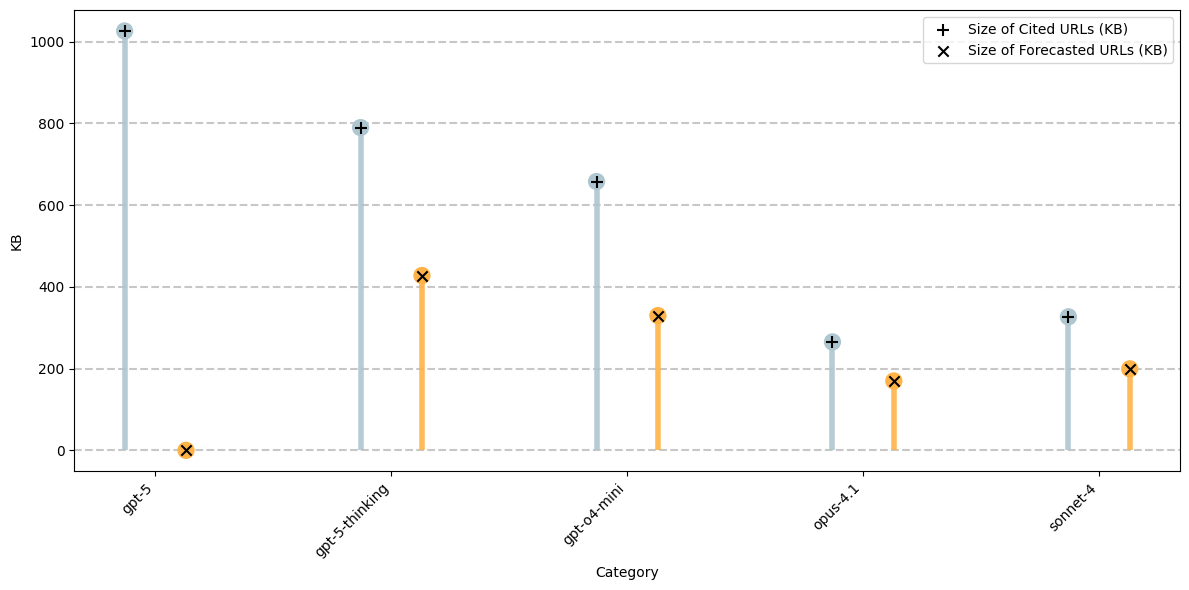

                accessed_bytes   cited_bytes  non_cited_bytes  \
model                                                           
gpt-5             1.830633e+06  1.050440e+06     7.801933e+05   
gpt-5-thinking    9.021101e+06  8.084361e+05     8.212665e+06   
gpt-o4-mini       3.089881e+06  6.733573e+05     2.416524e+06   
opus-4.1          7.478597e+05  2.716592e+05     4.762004e+05   
sonnet-4          9.914242e+05  3.344759e+05     6.569483e+05   

                forecasted_bytes  cited_url_count  search_count  
model                                                            
gpt-5                   0.000000        11.913294      0.000000  
gpt-5-thinking     437954.270704         8.801819      8.860294  
gpt-o4-mini        337556.096031         9.105273      4.633998  
opus-4.1           173898.220856         4.368935      1.016851  
sonnet-4           204206.596522         4.737196      1.022961  


In [63]:
combined_df = plot_category_bytes(averages_by_cat, averages_by_cat_is_cited, forcast_overall,
                                  save_path="images/bytes_by_category_plot4.svg",
                                  log_scale=False)
print(combined_df.head())